In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<img src="https://www.evernote.com/l/AAFyWbRBljJIqqUfNcOo8SvvvPa3gCnvCsAB/image.png" width="400px">

In [2]:
data_df = pd.read_pickle('../data/ball_on_spring.p')

In [3]:
data_df.sample(4)

,x_a,x_b,x_c,y_a,y_b,y_c
15,0.422004,1.024339,0.202091,0.296955,0.015444,0.257555
66,-1.595204,-1.676850,-0.423757,-0.304001,1.043921,-1.208805
9,-0.748080,-0.054267,-0.096980,-0.408881,0.648854,-0.817978
14,-0.041586,0.541629,0.267745,-0.036050,0.352663,0.196980


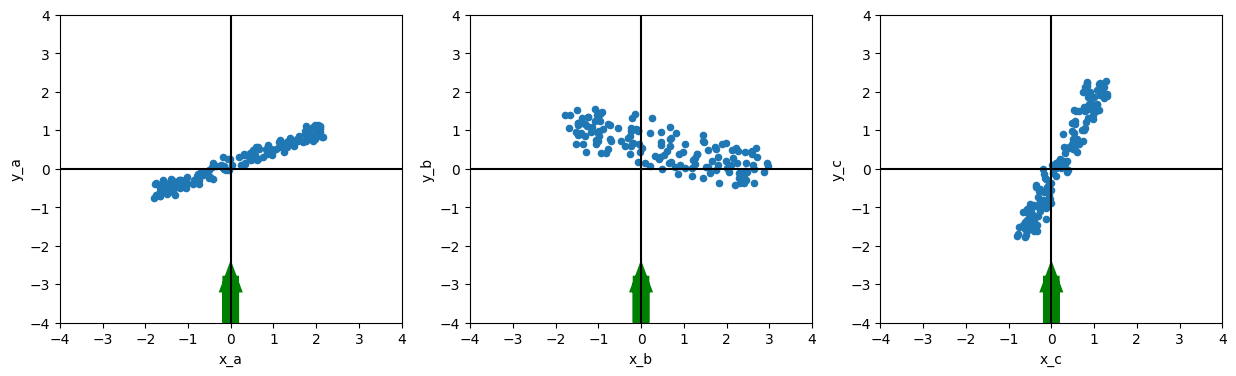

In [4]:
fig, ax = plt.subplots(1,3,figsize=(15,4))
for i, cam in enumerate(['a', 'b', 'c']):
    x_axis = 'x_{}'.format(cam)
    y_axis = 'y_{}'.format(cam)
    
    data_df.plot(x_axis, y_axis, kind='scatter', 
                 ax=ax[i], xlim=(-4,4), ylim=(-4,4))
    
    ax[i].axvline(c='black')
    ax[i].axhline(c='black')
    ax[i].arrow(0,-4,0,1,color='green',lw=12)

We can think of the green arrow as the camera.

### Variance and the Goal

At a high-level, our goal is to find a transformation for our data so that it is a "best expression" of the data.

Mathematically, this looks like this 

$$X' = PX$$

where $X$ is the original data and $X'$ is the transformed, "best expression" of the data. 

$P$ is a permutation or transformation matrix. 

# Assumptions and Limits

1. Linearity (or log linearity)
2. Scaled, Skew-Normal Data
3. Larger variances are more important
4. The principal components are orthogonal

### Numpy Derivation

Let $X$ be our data.

In [5]:
X = data_df

First look at $X^TX$.

**NOTE:** $X^TX$ is a symmetric matrix.

In [6]:
X.shape

(150, 6)

### Gramian Matrix

In [7]:
X.T.dot(X)

,x_a,x_b,x_c,y_a,y_b,y_c
x_a,254.954273,275.424476,119.254337,107.780297,-65.007718,249.042181
x_b,275.424476,334.865745,139.364607,123.337013,-37.233999,274.107207
x_c,119.254337,139.364607,64.360951,53.902928,-14.024867,119.723343
y_a,107.780297,123.337013,53.902928,49.631648,-18.353511,107.578879
y_b,-65.007718,-37.233999,-14.024867,-18.353511,82.891898,-56.055976
y_c,249.042181,274.107207,119.723343,107.578879,-56.055976,249.461675


In [8]:
(X.T @ X).shape

(6, 6)

Let's look at the covariance matrix of $X$.

In [9]:
X.cov()

,x_a,x_b,x_c,y_a,y_b,y_c
x_a,1.694996,1.783117,0.769402,0.701879,-0.506617,1.644996
x_b,1.783117,1.982120,0.809671,0.740596,-0.535297,1.732387
x_c,0.769402,0.809671,0.372432,0.320476,-0.229311,0.752708
y_a,0.701879,0.740596,0.320476,0.304457,-0.216953,0.686764
y_b,-0.506617,-0.535297,-0.229311,-0.216953,0.249290,-0.491601
y_c,1.644996,1.732387,0.752708,0.686764,-0.491601,1.630876


And the correlation matrix of $X$.

In [10]:
X.corr()

,x_a,x_b,x_c,y_a,y_b,y_c
x_a,1.000000,0.972816,0.968380,0.977046,-0.779368,0.989396
x_b,0.972816,1.000000,0.942367,0.953352,-0.761514,0.963540
x_c,0.968380,0.942367,1.000000,0.951720,-0.752575,0.965813
y_a,0.977046,0.953352,0.951720,1.000000,-0.787499,0.974617
y_b,-0.779368,-0.761514,-0.752575,-0.787499,1.000000,-0.770992
y_c,0.989396,0.963540,0.965813,0.974617,-0.770992,1.000000


There's no discernable pattern in there because the data is not conditioned.

### Conditioning The Data

Here we manually scale the data instead of importing `StandardScaler` from `sklearn.preprocessing`.

In [11]:
X.shape

(150, 6)

#### Center the Data

In [12]:
X.mean(), np.array(X).mean()

(x_a    0.126489
 x_b    0.513354
 x_c    0.243155
 y_a    0.168672
 y_b    0.552254
 y_c    0.207543
 dtype: float64,
 np.float64(0.301911226138733))

In [13]:
X_c = X - X.mean()

### $X_{c}^TX_{c}$

In [14]:
X_c.T.dot(X_c)

,x_a,x_b,x_c,y_a,y_b,y_c
x_a,252.554340,265.684407,114.640863,104.580021,-75.485861,245.104377
x_b,265.684407,295.335924,120.640940,110.348775,-79.759276,258.125727
x_c,114.640863,120.640940,55.492312,47.750928,-34.167360,112.153566
y_a,104.580021,110.348775,47.750928,45.364127,-32.325961,102.327875
y_b,-75.485861,-79.759276,-34.167360,-32.325961,37.144177,-73.248487
y_c,245.104377,258.125727,112.153566,102.327875,-73.248487,243.000536


### $X_{c}$ covariance

Note that `.cov()` calculates the **sample covariance** and is thus multiplied by a factor of $\frac{1}{n-1}$.

Here, we achieve identical results using `X_c.T.dot(X_c)/149` and `X.cov()`.

In [18]:
X_c.T.dot(X_c)/(len(X_c)-1)

,x_a,x_b,x_c,y_a,y_b,y_c
x_a,1.694996,1.783117,0.769402,0.701879,-0.506617,1.644996
x_b,1.783117,1.982120,0.809671,0.740596,-0.535297,1.732387
x_c,0.769402,0.809671,0.372432,0.320476,-0.229311,0.752708
y_a,0.701879,0.740596,0.320476,0.304457,-0.216953,0.686764
y_b,-0.506617,-0.535297,-0.229311,-0.216953,0.249290,-0.491601
y_c,1.644996,1.732387,0.752708,0.686764,-0.491601,1.630876


In [16]:
X.cov()

,x_a,x_b,x_c,y_a,y_b,y_c
x_a,1.694996,1.783117,0.769402,0.701879,-0.506617,1.644996
x_b,1.783117,1.982120,0.809671,0.740596,-0.535297,1.732387
x_c,0.769402,0.809671,0.372432,0.320476,-0.229311,0.752708
y_a,0.701879,0.740596,0.320476,0.304457,-0.216953,0.686764
y_b,-0.506617,-0.535297,-0.229311,-0.216953,0.249290,-0.491601
y_c,1.644996,1.732387,0.752708,0.686764,-0.491601,1.630876


##### Remember: assertions go silent when they pass

In [20]:
assert 1==1

In [22]:
assert 1==0, "one does not equal zero"

AssertionError: one does not equal zero

In [23]:
np.testing.assert_array_almost_equal(X_c.T.dot(X_c)/(len(X_c)-1), X.cov())

### $X_{sc}$ correlation

The correlation matrix is scaled data. 

Note that `.corr` calculates the **population correlation** and is the scaled data multiplied by a factor of $\frac1n$.

#### Scale the Data

In [24]:
X_sc = X_c/X.std(ddof=0)

In [25]:
X_sc.T.dot(X_sc)/len(X_sc)

,x_a,x_b,x_c,y_a,y_b,y_c
x_a,1.000000,0.972816,0.968380,0.977046,-0.779368,0.989396
x_b,0.972816,1.000000,0.942367,0.953352,-0.761514,0.963540
x_c,0.968380,0.942367,1.000000,0.951720,-0.752575,0.965813
y_a,0.977046,0.953352,0.951720,1.000000,-0.787499,0.974617
y_b,-0.779368,-0.761514,-0.752575,-0.787499,1.000000,-0.770992
y_c,0.989396,0.963540,0.965813,0.974617,-0.770992,1.000000


In [26]:
X.corr()

,x_a,x_b,x_c,y_a,y_b,y_c
x_a,1.000000,0.972816,0.968380,0.977046,-0.779368,0.989396
x_b,0.972816,1.000000,0.942367,0.953352,-0.761514,0.963540
x_c,0.968380,0.942367,1.000000,0.951720,-0.752575,0.965813
y_a,0.977046,0.953352,0.951720,1.000000,-0.787499,0.974617
y_b,-0.779368,-0.761514,-0.752575,-0.787499,1.000000,-0.770992
y_c,0.989396,0.963540,0.965813,0.974617,-0.770992,1.000000


In [27]:
np.testing.assert_array_almost_equal(X_sc.T.dot(X_sc)/len(X_sc), X.corr())

### This is Interesting

In [28]:
np.testing.assert_array_almost_equal(X_sc.corr(), X.corr())

Correlation is scale independent (think distributions).

## Datasets

### Conditioned Data
| dataset    | `numpy`                        | definition                                            |
|:-----------|--------------------------------|-------------------------------------------------------|
| $X$        | `X`                            | original                                              |
| $X_{c}$    | `X - X.mean()`                 | centered (subtract the mean)                          |
| $X_{sc}$   | `(X - X.mean())/X.std(ddof=0)` | scaled (subtract the mean, divide by std)             |

`ddof` is the delta degrees of freedom.

### Gramian Data
| dataset    | `numpy`                        | definition                                            |
|:-----------|--------------------------------|-------------------------------------------------------|
| $X^TX$     | `X.T.dot(X)` | the Gramian matrix for $X$ |
| $X_{cov}$  | `X.cov()` | pairwise covariance of columns, divided by $n-1$<br>$X_c^TX_c$, divided by $n-1$ |
| $X_{corr}$ | `X.corr()`| scaled, pairwise covariance, divided by $n$<br>$X_{sc}^TX_{sc}$, divided by $n$  |

##  EigenDecomposition of the Covariance

One tricky thing:

- `sklearn` uses the population covariance i.e. multiplied by $\frac{1}{n}$
- `pandas` uses the sample covariance i.e. multiplied by $\frac{1}{n-1}$


In [29]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X) # already scaled to the population covariance

PCA()

In [30]:
eig_vals_cov, eig_vecs_cov = np.linalg.eig(X.cov()*149/150) # before we compute the eigenvectors, we're scaling to the population covariance

In [31]:
eig_vals_man, eig_vecs_man = np.linalg.eig(X_c.T.dot(X_c)/150) # before we compute the eigenvectors, we're scaling to the population covariance

In [32]:
# computed using the covariance matrix
eig_vecs_cov = pd.DataFrame(eig_vecs_cov)
eig_vecs_cov

,0,1,2,3,4,5
0,0.528625,-0.263541,0.001416,-0.331938,-0.733398,-0.055179
1,0.566440,0.758522,-0.296237,0.022670,0.124434,0.005950
2,0.241480,-0.227596,-0.006879,0.031454,0.308616,-0.890846
3,0.220362,-0.127527,0.073880,0.936909,-0.222828,0.047630
4,-0.161074,-0.243701,-0.952225,0.065071,-0.060371,0.007335
5,0.516609,-0.477218,-0.001831,-0.079256,0.545988,0.448320


In [33]:
# the principal components from sklearn
pd.DataFrame(pca.components_.T)

,0,1,2,3,4,5
0,0.528625,-0.001416,-0.263541,0.055179,0.733398,-0.331938
1,0.566440,0.296237,0.758522,-0.005950,-0.124434,0.022670
2,0.241480,0.006879,-0.227596,0.890846,-0.308616,0.031454
3,0.220362,-0.073880,-0.127527,-0.047630,0.222828,0.936909
4,-0.161074,0.952225,-0.243701,-0.007335,0.060371,0.065071
5,0.516609,0.001831,-0.477218,-0.448320,-0.545988,-0.079256


In [34]:
# the eigenvectors of X_c^TX_c
eig_vecs_man = pd.DataFrame(eig_vecs_man)
eig_vecs_man

,0,1,2,3,4,5
0,0.528625,-0.263541,0.001416,-0.331938,-0.733398,-0.055179
1,0.566440,0.758522,-0.296237,0.022670,0.124434,0.005950
2,0.241480,-0.227596,-0.006879,0.031454,0.308616,-0.890846
3,0.220362,-0.127527,0.073880,0.936909,-0.222828,0.047630
4,-0.161074,-0.243701,-0.952225,0.065071,-0.060371,0.007335
5,0.516609,-0.477218,-0.001831,-0.079256,0.545988,0.448320


In [35]:
try:
    np.testing.assert_array_almost_equal(eig_vecs_cov, eig_vecs_man)
except:
    print("Manual and Covariance are not equal.")
try:
    np.testing.assert_array_almost_equal(pca.components_.T, eig_vecs_man)
except:
    print("Manual and PCA Components are not equal.")

Manual and PCA Components are not equal.


In [36]:
eig_vals_man, eig_vals_cov

(array([5.97160954, 0.07668919, 0.09709163, 0.01122894, 0.01549548,
        0.02049466]),
 array([5.97160954, 0.07668919, 0.09709163, 0.01122894, 0.01549548,
        0.02049466]))

In [37]:
pca.explained_variance_

array([6.01168746, 0.09774325, 0.07720389, 0.0206322 , 0.01559947,
       0.01130431])

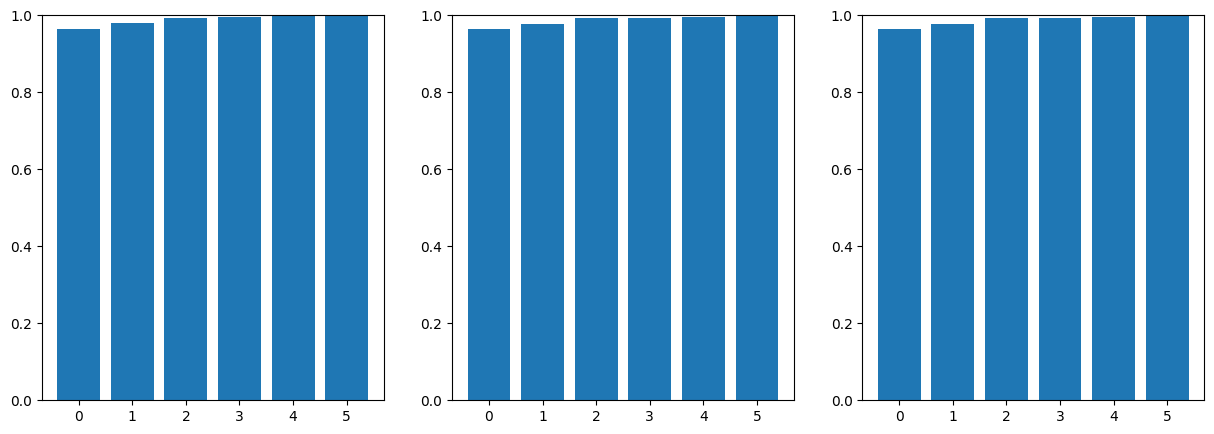

In [42]:
# using three subplots plot the cumulative sum of the explained variance
fig, ax = plt.subplots(1,3,figsize=(15,5))
ax[0].bar(height=np.cumsum(pca.explained_variance_ratio_), x=range(6))
ax[0].set_ylim(0,1)
ax[1].bar(height=np.cumsum(eig_vals_cov/np.sum(eig_vals_cov)), x=range(6))
ax[1].set_ylim(0,1)
ax[2].bar(height=np.cumsum(eig_vals_man/np.sum(eig_vals_man)), x=range(6))
ax[2].set_ylim(0,1)
plt.show()


# A Principal Component Analysis is the EigenDecomposition of the Population Covariance Matrix

### We can state the sklearn PCA algorithm as such

1. for data $A$
2. center the data $A_c = A - A_\mu$
2. calculate $A_c^TA_c$
3. divide $A_c^TA_c$ by $n$
4. find the eigendecomposition of this matrix, $S\Lambda S^T$
5. the explained variances are the eigenvalues, the principal components are S.

### Explained Variance Ratio

Explained variance ratio scales all of the explained variance values so that the sum of the explained variances is 1.

In [45]:
pca.explained_variance_ratio_

array([0.96431231, 0.01567863, 0.01238399, 0.00330953, 0.00250225,
       0.00181328])

Basically almost all of our data is captured by the first principal component. 

In [46]:
pca_1 = PCA(n_components=3)

In [47]:
pca_1_vec = pca_1.fit_transform(X)

In [48]:
tt = np.array(range(150))

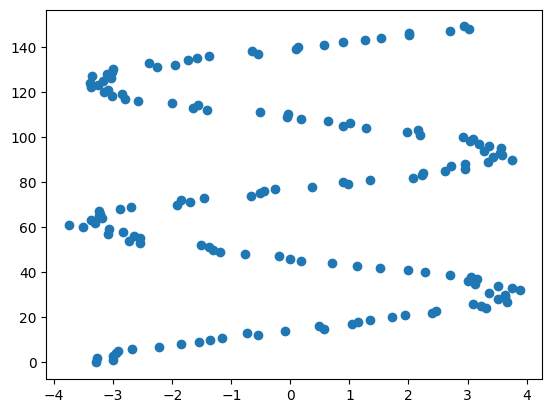

In [49]:
plt.scatter(pca_1_vec[:,0], tt)

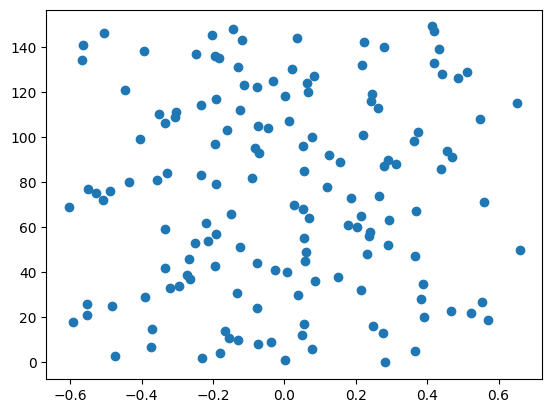

In [50]:
plt.scatter(pca_1_vec[:,1], tt)

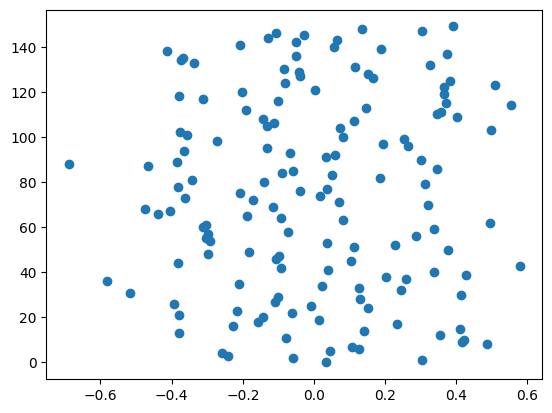

In [51]:
plt.scatter(pca_1_vec[:,2], tt)